![image.png](https://i.imgur.com/a3uAqnb.png)

# 🔍 Self-Supervised Learning vs Transfer Learning vs Training from Scratch on CIFAR-10 (10% Labeled)

This notebook compares three different training strategies for image classification using the CIFAR-10 dataset, especially in a low-label regime (only 1,000 labeled examples):

---

### 🧪 Goal:
To evaluate how well different approaches perform when trained on limited labeled data (5% or 500 images), using the full test set for evaluation.

---

### 🧱 Dataset Overview:
- **CIFAR-10**: 50,000 training images, 10,000 test images, 10 classes.
- **Labeled Subset**: Stratified 500 images (50 per class) used for fine-tuning and from-scratch training.
- **Unlabeled Subset**: Remaining 95% (49,500 images) used for SSL pretext task.

---

### 📊 Compared Strategies:

| Strategy               | Description                                                                 |
|------------------------|-----------------------------------------------------------------------------|
| ❌ **From Scratch**     | Train a CNN using only 500 labeled images.                               |
| 🌍 **Transfer Learning**| Fine-tune a ResNet18 pretrained on ImageNet using the same 500 images.   |
| 🧠 **SSL + Fine-Tune**  | Pretrain a CNN using a self-supervised rotation prediction task, then fine-tune on 500 labeled images. |

---

### 🧠 Pretext Task (SSL):
We train a CNN to predict the rotation angle (0°, 90°, 180°, 270°) of images from the 90% unlabeled training set. The learned features are then used for downstream classification with minimal labels.

---

### 🧾 Evaluation:
All models are evaluated on the **full 10,000-image test set**, and results are compared using accuracy.



### 🔧 Step 1: Import Libraries and Setup Device
This cell imports all necessary packages and checks for GPU availability.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.models as models
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
from collections import defaultdict
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set seed for reproducibility
random.seed(42)

### 🔁 Step 2: Create Rotation Dataset for SSL
- Rotates each image randomly by 0, 90, 180, or 270 degrees.
- The model must predict the rotation angle (pretext task).


In [33]:
class RotationDataset(Dataset):
    def __init__(self, dataset, reg=False):
        self.dataset = dataset
        self.angles = [0, 90, 180, 270]
        self.mapping = {0: (1, 0), 90: (0, 1), 180: (-1, 0), 270: (0, -1)}
        self.reg = reg

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        angle = random.choice(self.angles)
        rotated = transforms.functional.rotate(img, angle)
        if self.reg:
          label = self.mapping[angle]
        else:
          label = self.angles.index(angle)
        return rotated, label


### 📂 Step 3: Load CIFAR-10 & Split
- 1000 image of CIFAR-10 is used for training.
- The remaining is used for the SSL pretext task.


In [3]:
# Download full CIFAR-10 training dataset
import kagglehub, os, tarfile
path = kagglehub.dataset_download("pankrzysiu/cifar10-python")
tar_path = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".tar.gz")][0]

os.makedirs('./data', exist_ok=True)
with tarfile.open(tar_path) as tar:
    tar.extractall('./data')

Using Colab cache for faster access to the 'cifar10-python' dataset.


/tmp/ipykernel_1773/3362421304.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('./data')


In [4]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])
train_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)

In [28]:
# Step 1: Access labels
labels = train_full.targets
print(f"Shape: {len(labels)} | Sample: {labels[:10]}")

# Step 2: Group indices by class
class_indices = defaultdict(list) #it is a normal dict only diff is: accessing it with a key that doesn't exist is allowed
for idx, label in enumerate(labels):
    class_indices[label].append(idx)

print(class_indices.keys())

# Step 3: Stratified sample (50 per class => 500 total)
subset_indices = []
for class_id in range(10):
    sampled = random.sample(class_indices[class_id], 50)
    subset_indices.extend(sampled)

print(f"sample of the subset {subset_indices[:10]}")

# Fine-tuning / Supervised Subset (500 images)
train_subset = Subset(train_full, subset_indices)
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
train_reg_loader = DataLoader(RotationDataset(train_subset, reg=True), batch_size=64, shuffle=True)

# SSL uses the remaining data (full set minus the 500 labeled)
ssl_indices = list(set(range(len(train_full))) - set(subset_indices))
#just to check
print(f"number of leaked samples: {len(set(ssl_indices) & set(subset_indices))} ")
ssl_dataset_for_rotation = Subset(train_full, ssl_indices)
rotation_loader = DataLoader(RotationDataset(ssl_dataset_for_rotation), batch_size=128, shuffle=True)

# Test Set
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)


Shape: 50000 | Sample: [6, 9, 9, 4, 1, 1, 2, 7, 8, 3]
dict_keys([6, 9, 4, 1, 2, 7, 8, 3, 5, 0])
sample of the subset [32669, 35248, 13835, 6370, 47271, 341, 4540, 49263, 16392, 37690]
number of leaked samples: 0 


### 🧱 Step 4: Small CNN Model
A simple 2-layer CNN to be used for:
- SSL pretraining
- Scratch training

In [6]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


### ⚙️ Step 5: Train & Evaluate Functions
Modular training and evaluation


In [7]:
def train(model, loader, optimizer, criterion=None, epochs=10, desc="Training"):
    model.train()
    print(f"\n🔧 {desc} started...\n")
    for epoch in range(epochs):
        correct, total = 0, 0
        epoch_loss = 0
        pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            epoch_loss += loss.item()

            pbar.set_postfix(loss=loss.item(), acc=correct / total)

        print(f"✅ Epoch {epoch+1}: Accuracy = {correct/total:.2%}, Avg Loss = {epoch_loss/len(loader):.4f}")

    print(f"✅ {desc} completed.\n")

def evaluate(model, loader, desc="Evaluation"):
    model.eval()
    correct, total = 0, 0
    print(f"🔎 {desc} running...")
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=desc):
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"✅ {desc} Accuracy: {acc:.2%}\n")
    return acc


### 🧠 Step 6: SSL Pretext Training (Rotation)
Train the model to predict rotation angle using the 90% unlabeled data.


In [9]:
class RotationHead(nn.Module):
    def __init__(self):
        super().__init__()
        # pretrained classes: [0, 90, 180, 270]
        # using this to learn the features in the image
        self.backbone = SmallCNN(num_classes=4)

    def forward(self, x):
        return self.backbone(x)

print("🧠 Training SSL Pretext (Rotation on 90%)...")
rotation_model = RotationHead().to(device)
optimizer_ssl_pretext = torch.optim.Adam(rotation_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
train(rotation_model, rotation_loader, optimizer_ssl_pretext, criterion, epochs=25, desc="SSL Pretext Task")

ssl_backbone = rotation_model.backbone.features  # Extract backbone


🧠 Training SSL Pretext (Rotation on 90%)...

🔧 SSL Pretext Task started...



Epoch 1/25: 100%|██████████| 387/387 [00:27<00:00, 14.17it/s, acc=0.518, loss=0.955]


✅ Epoch 1: Accuracy = 51.76%, Avg Loss = 1.1117


Epoch 2/25: 100%|██████████| 387/387 [00:28<00:00, 13.63it/s, acc=0.605, loss=1.06]


✅ Epoch 2: Accuracy = 60.49%, Avg Loss = 0.9636


...

✅ Epoch 23: Accuracy = 76.06%, Avg Loss = 0.6078


Epoch 24/25: 100%|██████████| 387/387 [00:36<00:00, 10.60it/s, acc=0.762, loss=0.625]


✅ Epoch 24: Accuracy = 76.22%, Avg Loss = 0.6085


Epoch 25/25: 100%|██████████| 387/387 [00:31<00:00, 12.24it/s, acc=0.767, loss=0.675]

✅ Epoch 25: Accuracy = 76.70%, Avg Loss = 0.5958
✅ SSL Pretext Task completed.



### 🔁 Step 7: Fine-tune SSL Backbone
Freeze backbone learned from rotation task and train a small classifier.


In [21]:
class SSLClassifier(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        #taking the trained feature extractor
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False
        #adding classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)
class SSLRegression(nn.Module):
    def __init__(self, backbone):
      super().__init__()
      self.backbone = backbone
      for p in self.backbone.parameters():
        p.requires_grad = False
      # adding regression head
      self.output = nn.Sequential(
          nn.Flatten(),
          nn.Linear(64*8*8, 64), nn.ReLU(),
          nn.Linear(64, 1)
      )
    def forward(self, x):
      x = self.backbone(x)
      return self.output(x)

ssl_model = SSLClassifier(ssl_backbone).to(device)
optimizer_ssl_finetune = torch.optim.Adam(ssl_model.parameters(), lr=1e-3)
train(ssl_model, train_loader, optimizer_ssl_finetune,criterion, epochs=10, desc="SSL Fine-tune")
ssl_acc = evaluate(ssl_model, test_loader, desc="SSL Eval")



🔧 SSL Fine-tune started...



Epoch 1/10: 100%|██████████| 8/8 [00:00<00:00, 75.73it/s, acc=0.19, loss=2.11]


✅ Epoch 1: Accuracy = 19.00%, Avg Loss = 2.1936


Epoch 2/10: 100%|██████████| 8/8 [00:00<00:00, 78.61it/s, acc=0.548, loss=1.52]


✅ Epoch 2: Accuracy = 54.80%, Avg Loss = 1.7068


...

✅ Epoch 9: Accuracy = 97.20%, Avg Loss = 0.3410


Epoch 10/10: 100%|██████████| 8/8 [00:00<00:00, 75.99it/s, acc=0.986, loss=0.255]


✅ Epoch 10: Accuracy = 98.60%, Avg Loss = 0.2719
✅ SSL Fine-tune completed.

🔎 SSL Eval running...


SSL Eval: 100%|██████████| 157/157 [00:01<00:00, 95.72it/s]

✅ SSL Eval Accuracy: 48.15%



In [32]:
reg_model = SSLRegression(ssl_backbone).to(device)
optimizer_reg_finetune = torch.optim.Adam(reg_model.parameters(), lr=1e-3)
train(reg_model, train_reg_loader, optimizer_reg_finetune, nn.functional.mse_loss, epochs=10, desc="SSL Regression Fine-tune")
ssl_acc = evaluate(ssl_model, test_loader, desc="SSL Eval")


🔧 SSL Regression Fine-tune started...



Epoch 1/10:   0%|          | 0/8 [00:00<?, ?it/s]/tmp/ipykernel_1773/3156472454.py:11: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = criterion(outputs, labels)
Epoch 1/10:   0%|          | 0/8 [00:00<?, ?it/s]


RuntimeError: Found dtype Long but expected Float

### 🌍 Step 8: Transfer Learning with ResNet18
Fine-tune a model pretrained on ImageNet using 10% CIFAR-10.


In [15]:
print("📦 Transfer Learning with Pretrained ResNet18 (Frozen)...")

resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

# Freeze feature extractor
for p in resnet.parameters(): p.requires_grad = False
for p in resnet.fc.parameters(): p.requires_grad = True

resnet = resnet.to(device)
optimizer_resnet = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

train(resnet, train_loader, optimizer_resnet, criterion, epochs=25, desc="Transfer Learning (Frozen)")
resnet_acc = evaluate(resnet, test_loader, desc="Transfer Eval")


📦 Transfer Learning with Pretrained ResNet18 (Frozen)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]



🔧 Transfer Learning (Frozen) started...



Epoch 1/25: 100%|██████████| 8/8 [00:00<00:00, 16.35it/s, acc=0.122, loss=2.35]


✅ Epoch 1: Accuracy = 12.20%, Avg Loss = 2.5044


...

✅ Epoch 24: Accuracy = 77.60%, Avg Loss = 0.9123


Epoch 25/25: 100%|██████████| 8/8 [00:00<00:00, 48.86it/s, acc=0.734, loss=0.936]


✅ Epoch 25: Accuracy = 73.40%, Avg Loss = 0.9399
✅ Transfer Learning (Frozen) completed.

🔎 Transfer Eval running...


Transfer Eval: 100%|██████████| 157/157 [00:02<00:00, 55.87it/s]

✅ Transfer Eval Accuracy: 30.89%



### 🏗️ Step 9: Train From Scratch
Train the same small CNN from scratch using only 10% labeled data.


In [16]:
print("🧪 Training From Scratch...")

scratch_model = SmallCNN(num_classes=10).to(device)
optimizer_scratch = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)
train(scratch_model, train_loader, optimizer_scratch, criterion, epochs=10, desc="From Scratch")
scratch_acc = evaluate(scratch_model, test_loader, desc="Scratch Eval")


🧪 Training From Scratch...

🔧 From Scratch started...



Epoch 1/10: 100%|██████████| 8/8 [00:00<00:00, 58.70it/s, acc=0.094, loss=2.29]


✅ Epoch 1: Accuracy = 9.40%, Avg Loss = 2.3036


Epoch 2/10: 100%|██████████| 8/8 [00:00<00:00, 62.73it/s, acc=0.244, loss=2.17]


✅ Epoch 2: Accuracy = 24.40%, Avg Loss = 2.2248


...

✅ Epoch 9: Accuracy = 49.20%, Avg Loss = 1.5009


Epoch 10/10: 100%|██████████| 8/8 [00:00<00:00, 58.98it/s, acc=0.482, loss=1.32]


✅ Epoch 10: Accuracy = 48.20%, Avg Loss = 1.4822
✅ From Scratch completed.

🔎 Scratch Eval running...


Scratch Eval: 100%|██████████| 157/157 [00:01<00:00, 91.74it/s]

✅ Scratch Eval Accuracy: 35.81%



### 📊 Step 10: Compare Accuracies
Show all three methods side-by-side in a bar plot.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


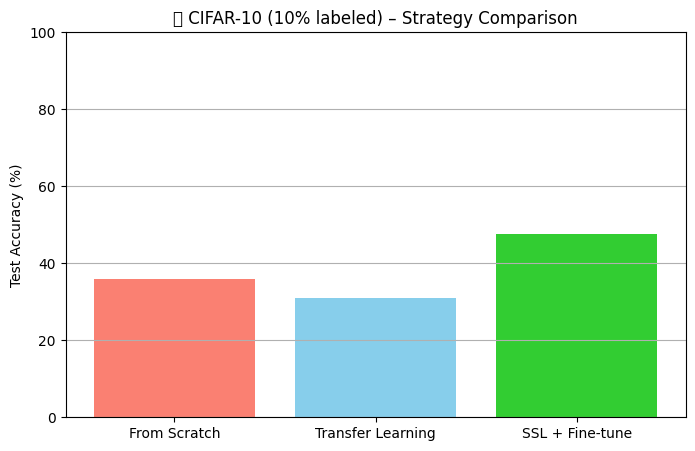

From Scratch: 35.81%
Transfer Learning: 30.89%
SSL + Fine-tune: 47.70%


In [17]:
labels = ["From Scratch", "Transfer Learning", "SSL + Fine-tune"]
scores = [scratch_acc * 100, resnet_acc * 100, ssl_acc * 100]

plt.figure(figsize=(8, 5))
plt.bar(labels, scores, color=["salmon", "skyblue", "limegreen"])
plt.ylabel("Test Accuracy (%)")
plt.title("📊 CIFAR-10 (10% labeled) – Strategy Comparison")
plt.ylim(0, 100)
plt.grid(axis="y")
plt.show()

for label, score in zip(labels, scores):
    print(f"{label}: {score:.2f}%")


### 📝 Try This: Turn Rotation Prediction into a Regression Problem

So far, `RotationDataset` treats rotation prediction as a **classification problem** — the model
picks one of 4 fixed classes (0°, 90°, 180°, 270°).

🔧 **Your task:** modify the pretext task so the model predicts a **continuous rotation angle
between 0° and 360°** instead of a class index.



### contributed by: Yazan Alshoibi